# 03 – Analysis

**Input:** data/processed/meals_clean.csv (17,076 meals, 23 canteens, 13 cities)

**Questions**
1. How do main dish prices for students differ between cities?
2. Are vegan main dishes cheaper than meat main dishes (within the same canteen)?
3. How did main dish prices change between 2024 and 2026?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/meals_clean.csv", parse_dates=["date"])
print(df.shape)
df.dtypes

(17076, 13)


id                           int64
name                           str
category                       str
notes                          str
canteen_id                   int64
canteen_name                   str
city                           str
date                datetime64[us]
prices.students            float64
prices.employees           float64
prices.others              float64
meal_type                      str
meal_role                      str
dtype: object

In [2]:
mains = df[df["meal_role"] == "main"].copy()
print("Main dishes:", len(mains))

Main dishes: 9602


In [3]:
buffet_like = mains["name"].str.lower().str.contains("zur wahl")
mains[buffet_like].groupby("canteen_name")["prices.students"].agg(["count", "median"])

,count,median
canteen_name,,
"Chemnitz, Straße der Nationen, Mensa",1,4.6


## Q1 – How do main dish prices differ between cities?
I use the **median** student price, because a few expensive specials would distort the mean.

In [4]:
city_prices = (
    mains.groupby("city")["prices.students"]
    .agg(["count", "median", "mean", "min", "max"])
    .round(2)
    .sort_values("median")
)
city_prices

,count,median,mean,min,max
city,,,,,
Leipzig,1317,2.10,2.60,1.70,4.50
Heidelberg,169,2.90,3.10,2.90,5.50
Passau,425,3.10,3.32,2.00,6.20
Köln,724,3.30,3.54,2.55,7.75
Straubing,254,3.30,3.51,2.00,6.50
Nürnberg,725,3.49,3.56,2.43,5.99
Dresden,925,3.60,3.53,2.18,5.10
Saarbrücken / Saarland,732,3.70,4.17,2.30,7.90
Regensburg,725,3.80,3.56,2.00,6.50


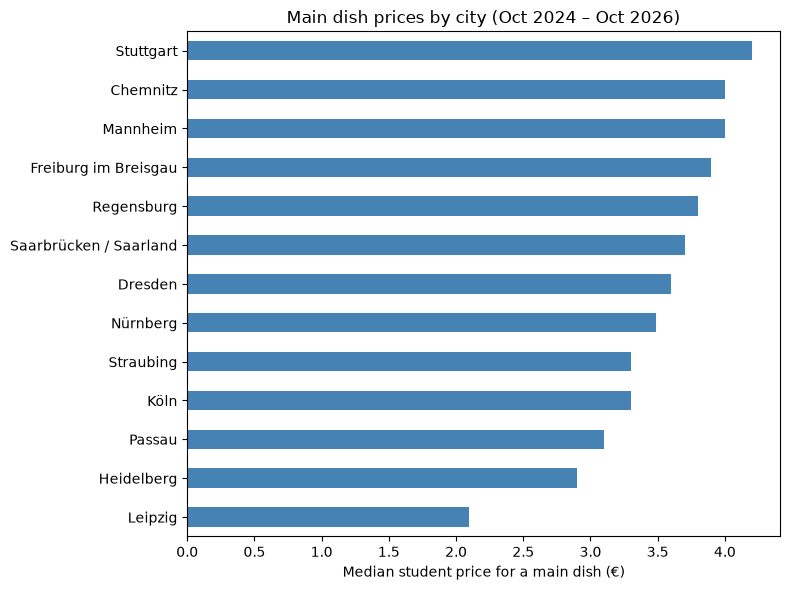

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

city_prices["median"].plot(kind="barh", ax=ax, color="steelblue")

ax.set_xlabel("Median student price for a main dish (€)")
ax.set_ylabel("")
ax.set_title("Main dish prices by city (Oct 2024 – Oct 2026)")

plt.tight_layout()
plt.savefig("../reports/q1_median_price_by_city.png", dpi=150)
plt.show()

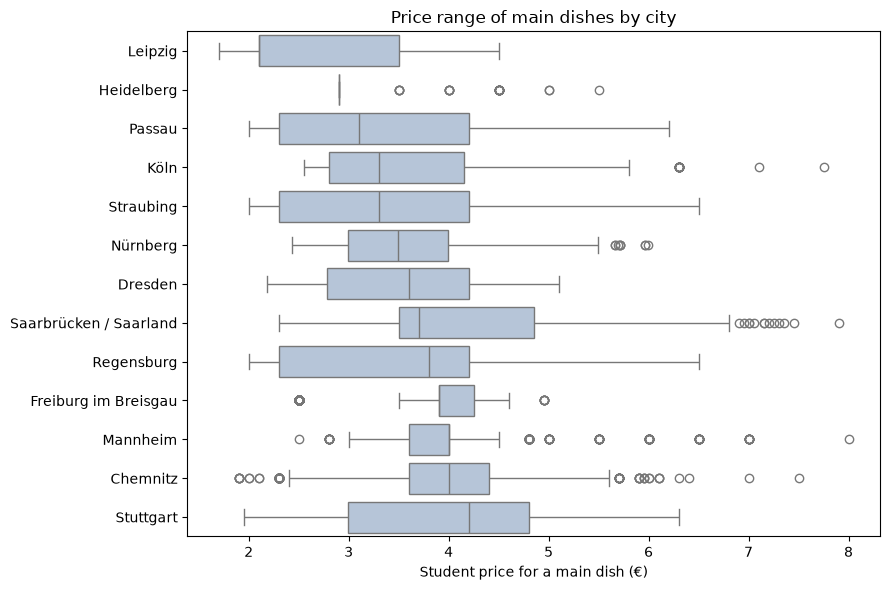

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(data=mains, x="prices.students", y="city",
            order=city_prices.index, color="lightsteelblue", ax=ax)

ax.set_xlabel("Student price for a main dish (€)")
ax.set_ylabel("")
ax.set_title("Price range of main dishes by city")

plt.tight_layout()
plt.savefig("../reports/q1_price_range_by_city.png", dpi=150)
plt.show()

In [7]:
  mains[(mains["city"] == "Freiburg im Breisgau") & (mains["prices.students"] < 2)][["name", "prices.students"]].head(10)

,name,prices.students


### Findings Q1
- **Cheapest:** Leipzig, median €2.10 per main dish. Leipzig offers cheap dishes every day
  (e.g. Germknödel, Kartoffelpuffer for €1.70), so its mean (€2.60) is clearly above its median.
- **Most expensive:** Stuttgart (€4.20), followed by Mannheim and Chemnitz (€4.00).
  Stuttgart is represented by only one small art-academy cafeteria (211 mains), so it's not representative of the whole city.
- **Difference:** about €1.90 per main dish between Leipzig and Mannheim/Chemnitz.
  For a student eating at the Mensa 20 days a month, that's roughly **€38 per month**.
- **Region is not the explanation:** Leipzig and Dresden (Saxony) are among the cheaper cities,
  but Chemnitz (also Saxony) is among the most expensive. Each Studierendenwerk sets its own prices.
- **Caveats:** each city is represented by only 1–2 canteens. Heidelberg prices by component
  (many mains at exactly €2.90), so its prices may be lower than a full plate elsewhere.

## Q2 – Are vegan main dishes cheaper than meat main dishes?
Labelling differs between canteens, so I compare meal types **within each canteen**
and only use canteens with enough labelled vegan and meat dishes.

In [8]:
typed = mains[mains["meal_type"].isin(["vegan", "vegetarian", "meat", "fish"])].copy()
print("Main dishes with a known type:", len(typed))

typed.groupby("meal_type")["prices.students"].agg(["count", "median"]).round(2)

Main dishes with a known type: 8197


,count,median
meal_type,,
fish,328,4.20
meat,3573,3.89
vegan,2569,3.00
vegetarian,1727,3.70


In [9]:
counts = typed.pivot_table(index="canteen_name", columns="meal_type",
                           values="prices.students", aggfunc="count", fill_value=0)

medians = typed.pivot_table(index="canteen_name", columns="meal_type",
                            values="prices.students", aggfunc="median")

counts

meal_type,fish,meat,vegan,vegetarian
canteen_name,,,,
Cafeteria Nikolakloster Passau,6,15,46,31
"Chemnitz, Reichenhainer Straße, Mensa",16,178,0,126
"Chemnitz, Straße der Nationen, Mensa",37,224,1,248
"Dresden, Alte Mensa",43,267,164,144
"Dresden, Mensa Matrix",4,179,71,26
"Heidelberg, Mensa Im Neuenheimer Feld 304",0,13,63,0
"Heidelberg, Triplex-Mensa am Uniplatz",0,0,36,2
"Köln, Mensa Südstadt",2,92,110,17
"Köln, Mensa Zülpicher Straße",0,151,183,103


In [10]:
MIN_N = 30     # at least 30 vegan AND 30 meat main dishes

enough = (counts["vegan"] >= MIN_N) & (counts["meat"] >= MIN_N)

comp = medians.loc[enough, ["vegan", "vegetarian", "meat"]].round(2)
comp["meat_minus_vegan"] = (comp["meat"] - comp["vegan"]).round(2)
comp = comp.sort_values("meat_minus_vegan")
comp

meal_type,vegan,vegetarian,meat,meat_minus_vegan
canteen_name,,,,
"Leipzig, Mensa Academica",2.50,2.65,2.10,-0.40
"Leipzig, Mensa am Park",2.40,2.65,2.10,-0.30
Mensa / Mensacafe Saarbrücken,3.85,4.75,3.70,-0.15
"Dresden, Mensa Matrix",4.39,4.14,4.29,-0.10
"Mannheim, Mensaria Metropol",4.00,3.50,4.00,0.00
"Mannheim, Mensa am Schloss",4.00,NaN,4.00,0.00
"Dresden, Alte Mensa",2.78,3.18,2.82,0.04
Mensa Regensburger Straße,3.21,2.99,3.54,0.33
Mensa Institutsviertel,3.90,3.90,4.25,0.35


In [11]:
print("Canteens compared:", len(comp))
print("Vegan cheaper in:", (comp["meat_minus_vegan"] > 0).sum())
print("Same price in:", (comp["meat_minus_vegan"] == 0).sum())
print("Vegan more expensive in:", (comp["meat_minus_vegan"] < 0).sum())
print("Typical difference (median):", comp["meat_minus_vegan"].median(), "€")

Canteens compared: 17
Vegan cheaper in: 11
Same price in: 2
Vegan more expensive in: 4
Typical difference (median): 0.35 €


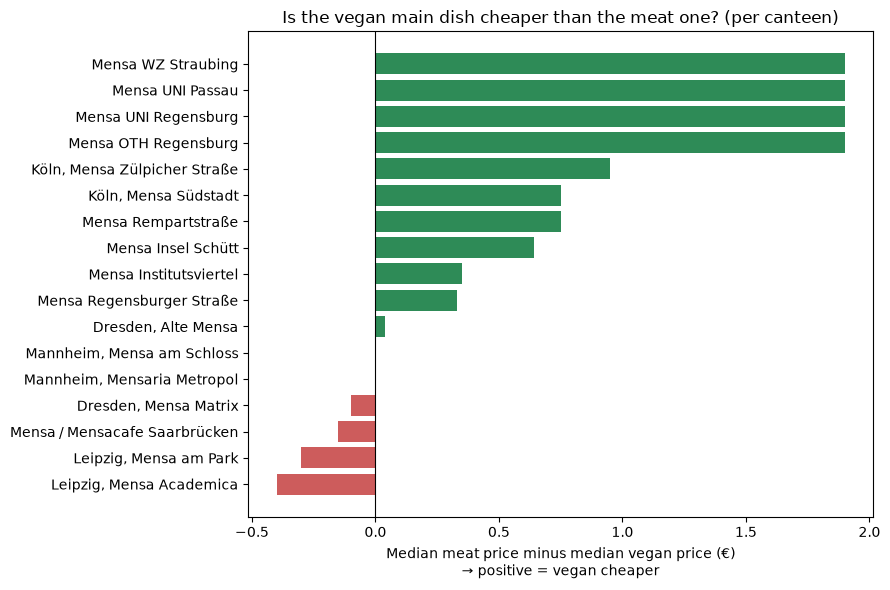

In [12]:
colors = ["seagreen" if d > 0 else "indianred" for d in comp["meat_minus_vegan"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(comp.index, comp["meat_minus_vegan"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_xlabel("Median meat price minus median vegan price (€)\n→ positive = vegan cheaper")
ax.set_title("Is the vegan main dish cheaper than the meat one? (per canteen)")

plt.tight_layout()
plt.savefig("../reports/q2_vegan_vs_meat_by_canteen.png", dpi=150)
plt.show()

### Findings Q2
- **Naive comparison:** vegan mains €3.00 vs meat €3.89 (median), €0.89 cheaper.
- **Within canteens** (17 canteens with ≥30 vegan and ≥30 meat mains): vegan is cheaper in 11, the same in 2,
  and more expensive in 4. The typical difference is only **€0.35**.
- **Why the naive gap is bigger:** the canteens with the biggest gap (Regensburg, Passau, Straubing: €1.90)
  also have many vegan dishes, so they dominate the overall vegan median (composition effect).
- **Different pricing policies:**
  - *Tiered* (Studierendenwerk Niederbayern/Oberpfalz): vegan €2.30, vegetarian €3.10, meat €4.20, identical in all 4 canteens.
  - *Flat* (Mannheim): €4.00 regardless of meal type.
  - *Cheap meat option* (Leipzig): meat €2.10 vs vegan €2.40–2.50.
- **Excluded:** Heidelberg, Chemnitz, Stuttgart and Passau Nikolakloster, which don't have enough labelled vegan or meat mains.

## Q3 – How did main dish prices change between 2024 and 2026?
First an overall monthly view, then a fair comparison per canteen:
Year 1 (Oct 2024 – Sep 2025) vs Year 2 (Oct 2025 – Sep 2026).

In [13]:
mains["month"] = mains["date"].dt.to_period("M")

monthly = mains.groupby("month").agg(
    median_price=("prices.students", "median"),
    meals=("prices.students", "count"),
)
monthly

,median_price,meals
month,,
2024-10,3.250,493
2024-11,3.250,387
2024-12,3.500,321
2025-01,3.430,430
2025-02,3.650,383
2025-03,3.600,361
2025-04,3.600,504
2025-05,3.625,444
2025-06,3.600,419


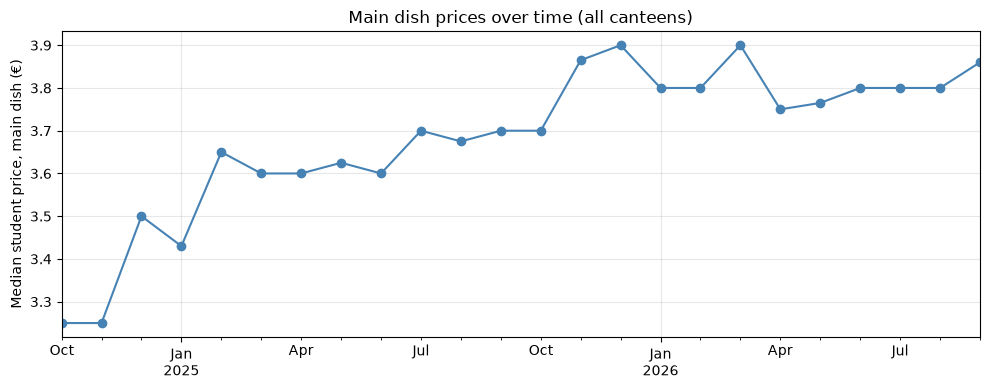

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

monthly["median_price"].plot(ax=ax, marker="o", color="steelblue")

ax.set_ylabel("Median student price, main dish (€)")
ax.set_xlabel("")
ax.set_title("Main dish prices over time (all canteens)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/q3_monthly_median_price.png", dpi=150)
plt.show()

In [15]:
import numpy as np

mains["year"] = np.where(mains["date"] < "2025-10-01", "Y1", "Y2")

year_counts = mains.pivot_table(index="canteen_name", columns="year",
                                values="prices.students", aggfunc="count", fill_value=0)
year_medians = mains.pivot_table(index="canteen_name", columns="year",
                                 values="prices.students", aggfunc="median")

enough_y = (year_counts["Y1"] >= 30) & (year_counts["Y2"] >= 30)

change = year_medians.loc[enough_y].round(2)
change["change_eur"] = (change["Y2"] - change["Y1"]).round(2)
change["change_pct"] = (change["change_eur"] / change["Y1"] * 100).round(1)
change = change.sort_values("change_pct")
change

year,Y1,Y2,change_eur,change_pct
canteen_name,,,,
Mensa OTH Regensburg,4.20,3.80,-0.40,-9.5
Cafeteria Nikolakloster Passau,3.00,2.80,-0.20,-6.7
Mensa Regensburger Straße,3.45,3.39,-0.06,-1.7
"Dresden, Mensa Matrix",4.37,4.34,-0.03,-0.7
"Leipzig, Mensa am Park",2.10,2.10,0.00,0.0
"Leipzig, Mensa Academica",2.40,2.40,0.00,0.0
"Heidelberg, Mensa Im Neuenheimer Feld 304",2.90,2.90,0.00,0.0
"Chemnitz, Reichenhainer Straße, Mensa",3.80,3.80,0.00,0.0
Mensa Institutsviertel,3.90,3.90,0.00,0.0


In [16]:
print("Canteens compared:", len(change))
print("More expensive:", (change["change_pct"] > 0).sum())
print("Same price:", (change["change_pct"] == 0).sum())
print("Cheaper:", (change["change_pct"] < 0).sum())
print("Typical change (median):", change["change_pct"].median(), "%")

Canteens compared: 22
More expensive: 11
Same price: 7
Cheaper: 4
Typical change (median): 1.0 %


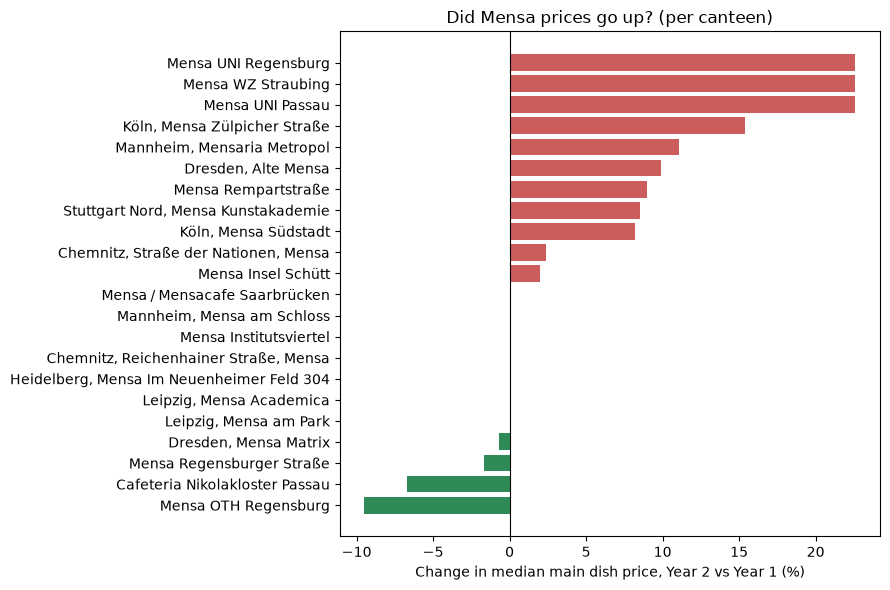

In [17]:
colors = ["indianred" if c > 0 else "seagreen" for c in change["change_pct"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(change.index, change["change_pct"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_xlabel("Change in median main dish price, Year 2 vs Year 1 (%)")
ax.set_title("Did Mensa prices go up? (per canteen)")

plt.tight_layout()
plt.savefig("../reports/q3_price_change_by_canteen.png", dpi=150)
plt.show()

In [18]:
meat_only = mains[mains["meal_type"] == "meat"]
m = meat_only.pivot_table(index="canteen_name", columns="year",
                          values="prices.students", aggfunc="median").dropna()
m["change_pct"] = ((m["Y2"] - m["Y1"]) / m["Y1"] * 100).round(1)
print("Typical change, meat mains only:", m["change_pct"].median(), "%")

Typical change, meat mains only: 0.0 %


In [20]:
dish_year = (
    mains.groupby(["canteen_name", "name", "year"])["prices.students"]
    .median()
    .unstack("year")
    .dropna()
)
dish_year["change_pct"] = ((dish_year["Y2"] - dish_year["Y1"]) / dish_year["Y1"] * 100).round(1)

print("Dishes offered in both years:", len(dish_year))
print("Typical change, same dishes (median):", dish_year["change_pct"].median(), "%")
print("Share of dishes that got more expensive:", round((dish_year["change_pct"] > 0).mean() * 100), "%")

Dishes offered in both years: 591
Typical change, same dishes (median): 0.0 %
Share of dishes that got more expensive: 28 %


In [21]:
dish_year.groupby("canteen_name")["change_pct"].agg(["count", "median"]).round(1).sort_values("median")

,count,median
canteen_name,,
"Dresden, Mensa Matrix",3,-7.3
"Chemnitz, Reichenhainer Straße, Mensa",7,-2.9
"Chemnitz, Straße der Nationen, Mensa",9,-2.9
Cafeteria Nikolakloster Passau,12,0.0
"Dresden, Alte Mensa",15,0.0
"Heidelberg, Mensa Im Neuenheimer Feld 304",8,0.0
"Heidelberg, Triplex-Mensa am Uniplatz",6,0.0
"Köln, Mensa Zülpicher Straße",15,0.0
"Mannheim, Mensaria Metropol",13,0.0


In [22]:
m.sort_values("change_pct")

year,Y1,Y2,change_pct
canteen_name,,,
"Heidelberg, Mensa Im Neuenheimer Feld 304",4.500,4.00,-11.1
Mensa / Mensacafe Saarbrücken,3.925,3.65,-7.0
"Chemnitz, Reichenhainer Straße, Mensa",4.100,3.90,-4.9
"Dresden, Mensa Matrix",4.305,4.29,-0.3
"Mannheim, Mensaria Metropol",4.000,4.00,0.0
"Mannheim, Mensa am Schloss",4.000,4.00,0.0
"Leipzig, Mensa am Park",2.100,2.10,0.0
"Dresden, Alte Mensa",2.820,2.82,0.0
Mensa Regensburger Straße,3.540,3.54,0.0


### Findings Q3
- **The naive view is misleading:** the monthly median of all main dishes rose from €3.25 (Oct 2024)
  to €3.86 (Sep 2026), about +19%. Per canteen, the median of all mains changed by only +1.0% (typical).
- **Like-for-like comparison:** for the same dish in the same canteen (591 dishes offered in both years),
  the typical price change was **0.0%**. Only 28% of these dishes got more expensive.
- **Where prices rose, they rose moderately:** about +5% in the Studierendenwerk Niederbayern/Oberpfalz canteens
  (meat €4.20 → €4.40 in Regensburg and Straubing) and in Stuttgart (+5.1%).
- **Why the naive numbers were higher:** the menu mix changed (e.g. more dishes in higher price tiers),
  so medians moved even when prices didn't. Example: UNI Regensburg's median of all mains rose 22.6%,
  but the same dishes only rose 4.8%.
- **Caveats:** only exact dish-name matches are compared. Canteens with fewer than ~10 matched dishes
  (Dresden Matrix, Köln Südstadt, Heidelberg Triplex, Chemnitz) are not reliable on their own.